In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import log_loss
from sklearn.inspection import permutation_importance
from scipy.stats import randint, uniform, loguniform
import joblib
import warnings

from tfm_segunda.evaluate_models import evaluar_modelo, graficar_matriz_confusion

warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

PROJECT_ROOT = Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True, parents=True)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100


In [2]:
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')
PROJECT_ROOT = Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True, parents=True)
SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
dataset_path = DATA_PROCESSED / "dataset_modelado.parquet"
df = pd.read_parquet(dataset_path)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\nFilas por split:")
print(df['split'].value_counts())
train = df[df['split'] == 'train'].copy()
validation = df[df['split'] == 'validation'].copy()
test = df[df['split'] == 'test'].copy()

print(f"Train:      {len(train):>5,} filas  |  fechas {train['date'].min().date()} → {train['date'].max().date()}")
print(f"Validation: {len(validation):>5,} filas  |  fechas {validation['date'].min().date()} → {validation['date'].max().date()}")
print(f"Test:       {len(test):>5,} filas  |  fechas {test['date'].min().date()} → {test['date'].max().date()}")
META_COLS = ['split', 'season', 'date', 'jornada', 'home_team', 'away_team', 'fthg', 'ftag']
TARGET_COLS = ['ftr']
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + TARGET_COLS]

Dataset cargado: 7,295 filas × 41 columnas

Filas por split:
split
train         4592
validation    1373
test           923
demo           407
Name: count, dtype: int64
Train:      4,592 filas  |  fechas 2010-08-27 → 2020-08-07
Validation: 1,373 filas  |  fechas 2020-09-12 → 2023-05-28
Test:         923 filas  |  fechas 2023-08-11 → 2025-06-01


In [3]:
def preparar_xy(particion, feature_cols):
    mask_completas = particion[feature_cols].notna().all(axis=1)
    p = particion.loc[mask_completas].copy()
    
    X = p[feature_cols].astype(float)
    y = p['ftr']
    return X, y


X_train, y_train = preparar_xy(train, FEATURE_COLS)
X_val, y_val = preparar_xy(validation, FEATURE_COLS)
X_test, y_test = preparar_xy(test, FEATURE_COLS)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


X_train: (4482, 32), y_train: (4482,)
X_val: (1338, 32), y_val: (1338,)
X_test: (901, 32), y_test: (901,)


In [ ]:
le = LabelEncoder().fit(y_train)
y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

scaler = StandardScaler().fit(X_train)
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=FEATURE_COLS, index=X_train.index)
X_val_s   = pd.DataFrame(scaler.transform(X_val),   columns=FEATURE_COLS, index=X_val.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=FEATURE_COLS, index=X_test.index)

print("Clases:", list(le.classes_))
print(f"X_train escalado: media≈{X_train_s.mean().mean():.3f}, std≈{X_train_s.std().mean():.3f}")


Clases: ['A', 'D', 'H']
X_train escalado: media≈-0.000, std≈1.000


In [ ]:
ARQUITECTURAS = [
    (16,),
    (32,),
    (64,),
    (32, 16),
    (64, 32),
    (64, 32, 16),
    (128, 64),
]

param_dist = {
    'hidden_layer_sizes': ARQUITECTURAS,
    'activation':         ['relu', 'tanh'],
    'alpha':              loguniform(1e-5, 1e-1),
    'learning_rate_init': loguniform(1e-4, 1e-2),
    'batch_size':         [32, 64, 128, 'auto'],
}

mlp_base = MLPClassifier(
    solver='adam',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=SEED,
)

rs = RandomizedSearchCV(
    estimator           = mlp_base,
    param_distributions = param_dist,
    n_iter              = 60,
    cv                  = TimeSeriesSplit(n_splits=5),
    scoring             = 'neg_log_loss',
    n_jobs              = -1,
    verbose             = 1,
    refit               = True,
    random_state        = SEED,
)
rs.fit(X_train_s, y_train_enc)
print("Mejores params:", rs.best_params_)
print(f"Mejor log-loss CV: {-rs.best_score_:.4f}")


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Mejores params: {'activation': 'relu', 'alpha': np.float64(1.5339162591163613e-05), 'batch_size': 128, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': np.float64(0.00021930485556643703)}
Mejor log-loss CV: 1.0622


In [6]:
bp = rs.best_params_
fine_grid = {
    'hidden_layer_sizes': [bp['hidden_layer_sizes']],
    'activation':         [bp['activation']],
    'alpha':              [bp['alpha']*0.3, bp['alpha'], bp['alpha']*3],
    'learning_rate_init': [max(1e-5, bp['learning_rate_init']*0.5),
                           bp['learning_rate_init'],
                           min(1e-2, bp['learning_rate_init']*2)],
    'batch_size':         [bp['batch_size']],
}

gs_fine = GridSearchCV(
    estimator   = MLPClassifier(
        solver='adam', max_iter=500,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
        random_state=SEED,
    ),
    param_grid = fine_grid,
    cv         = TimeSeriesSplit(n_splits=5),
    scoring    = 'neg_log_loss',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True,
)
gs_fine.fit(X_train_s, y_train_enc)
print("Mejores params (refinado):", gs_fine.best_params_)
print(f"Mejor log-loss CV refinado: {-gs_fine.best_score_:.4f}")

mlp_final = gs_fine.best_estimator_


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Mejores params (refinado): {'activation': 'relu', 'alpha': np.float64(1.5339162591163613e-05), 'batch_size': 128, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': np.float64(0.00010965242778321852)}
Mejor log-loss CV refinado: 1.0617


In [7]:
LABELS = ['A', 'D', 'H']
LOG_LOSS_MERCADO = 1.037

def evaluar_split_mlp(modelo, nombre_modelo, nombre_split, X, y_str):
    y_pred_enc = modelo.predict(X)
    y_pred = le.inverse_transform(y_pred_enc)
    y_proba = pd.DataFrame(
        modelo.predict_proba(X),
        columns=le.classes_,
    )[LABELS].values
    res = evaluar_modelo(y_str, y_pred, y_proba,
                         f'{nombre_modelo} · {nombre_split}',
                         verbose=False)
    res['variante'] = nombre_modelo
    res['split']    = nombre_split
    return res

filas = []
for nombre_split, X, y in [('train', X_train_s, y_train),
                            ('validation', X_val_s, y_val),
                            ('test', X_test_s, y_test)]:
    filas.append(evaluar_split_mlp(mlp_final, 'MLP', nombre_split, X, y))

tabla = (pd.DataFrame(filas)
         [['variante', 'split', 'accuracy', 'f1_macro',
           'f1_A', 'f1_D', 'f1_H', 'log_loss']]
         .assign(delta_vs_mercado=lambda d: d['log_loss'] - LOG_LOSS_MERCADO))

print(tabla.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


variante      split  accuracy  f1_macro   f1_A   f1_D   f1_H  log_loss  delta_vs_mercado
     MLP      train    0.4616    0.3000 0.1662 0.1074 0.6263    1.0544            0.0174
     MLP validation    0.4372    0.2884 0.1082 0.1541 0.6028    1.0651            0.0281
     MLP       test    0.4584    0.3028 0.1625 0.1166 0.6293    1.0533            0.0163


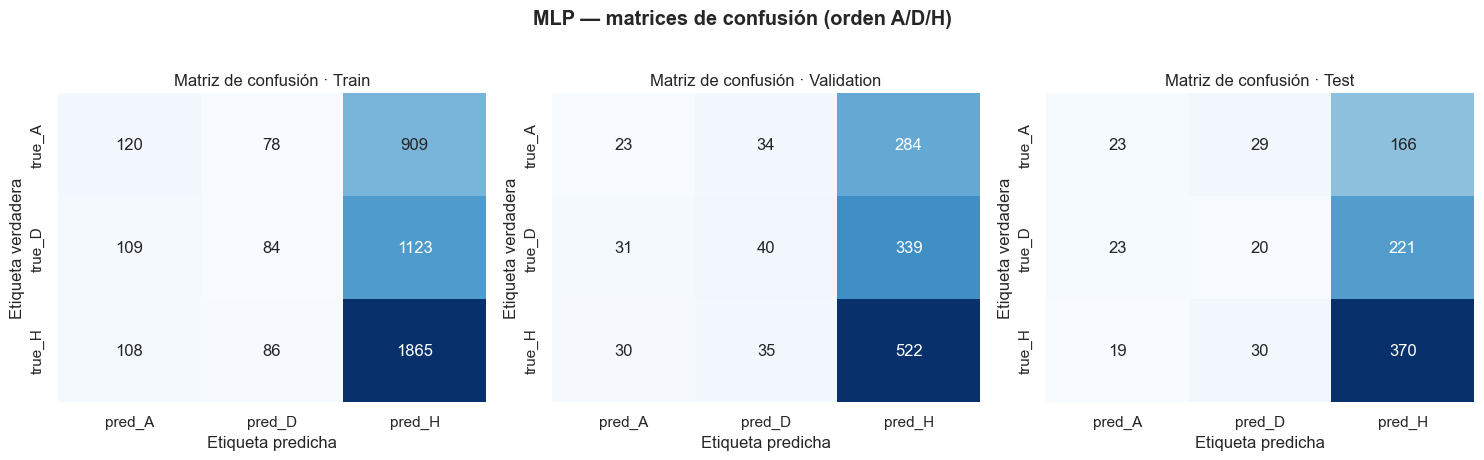

In [8]:
resultados = {
    'Train':      evaluar_split_mlp(mlp_final, 'MLP', 'Train',      X_train_s, y_train),
    'Validation': evaluar_split_mlp(mlp_final, 'MLP', 'Validation', X_val_s,   y_val),
    'Test':       evaluar_split_mlp(mlp_final, 'MLP', 'Test',       X_test_s,  y_test),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nombre, res) in zip(axes, resultados.items()):
    cm = np.array(res['confusion_matrix'])
    graficar_matriz_confusion(cm, LABELS, nombre, ax=ax)
plt.suptitle('MLP — matrices de confusión (orden A/D/H)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


Top features (MLP — permutación, ΔlogLoss):
prob_h               0.013986
home_mv              0.008731
home_gf_10           0.004569
home_ppg_5           0.003811
home_gc_5            0.002800
away_gf_10           0.002755
away_gf_5            0.002700
home_ppg_10          0.002356
match_uncertainty    0.002248
away_gf_3            0.002172
home_pos_pre         0.002168
home_gf_3            0.001879
home_elo_pre         0.001540
home_ppg_3           0.001370
away_gc_10           0.001162
home_gc_10           0.001054
away_ppg_3           0.000994
home_gd_pre          0.000829
home_rest_days       0.000804
home_gc_3            0.000431
away_gc_3            0.000421
away_ppg_10          0.000239
away_rest_days      -0.000036
home_gf_5           -0.000103
away_pos_pre        -0.000447
home_pts_pre        -0.000610
away_gc_5           -0.000691
away_gd_pre         -0.001331
away_pts_pre        -0.001531
away_ppg_5          -0.001830
away_mv             -0.001917
away_elo_pre        -0.003

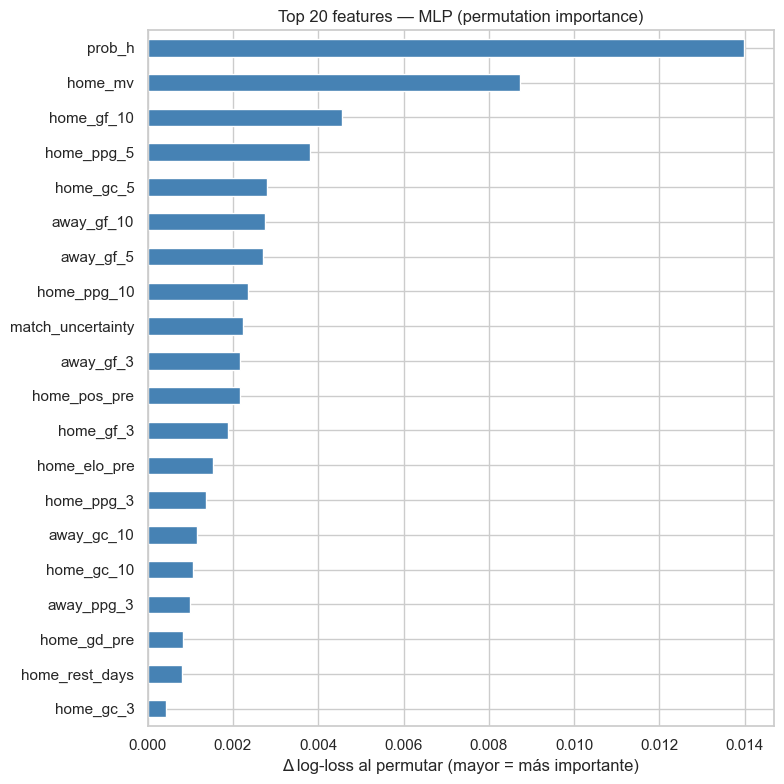

In [9]:
perm = permutation_importance(
    mlp_final, X_val_s, y_val_enc,
    n_repeats=20, random_state=SEED, scoring='neg_log_loss', n_jobs=-1,
)

importancias = (pd.Series(perm.importances_mean, index=FEATURE_COLS)
                .sort_values(ascending=False))

print("Top features (MLP — permutación, ΔlogLoss):")
print(importancias)

fig, ax = plt.subplots(figsize=(8, 8))
importancias.head(20).iloc[::-1].plot.barh(ax=ax, color='steelblue')
ax.set_title('Top 20 features — MLP (permutation importance)')
ax.set_xlabel('Δ log-loss al permutar (mayor = más importante)')
plt.tight_layout()
plt.show()


In [10]:
joblib.dump(mlp_final, MODELS_DIR / "mlp_final.pkl")

['/Users/pedrosarm/Desktop/TFM/Code/notebooks/models/mlp_final.pkl']